#### Trojan vs Non-Trojan M(v) distribution (ONE FILE)

[INFO] Reading: c432__trojan_andxor.v
[INFO] Parsing Verilog -> graph ...
[INFO] Graph: |V|=174 (gates), |E|=269
[INFO] Trojan gates detected by name pattern: 3 / 174
[INFO] Computing M(v) components + composite ... (approx, fast)

================ Distribution summary (M(v)) ================
Trojan nodes   : n=3 | mean=0.5808 | median=0.5848
Non-Trojan nodes: n=171 | mean=0.6328 | median=0.6508

[INFO] Skipping MannWhitney U (need >=5 samples per group).


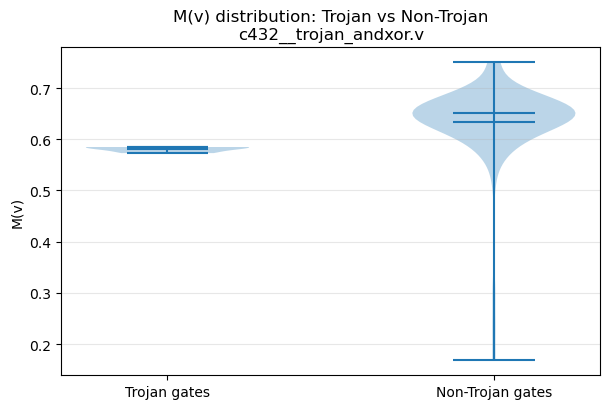


[DEBUG] First detected Trojan instances: ['U_tand_1520', 'U_txor_1520', 'U_tbuf_1520']


In [1]:
# ==========================
# Trojan vs Non-Trojan M(v) distribution (ONE FILE)
# ==========================
import os
import re
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- CONFIG ----------------
TROJAN_DIR = Path("verilog_benchmark_circuits_Trojan")

# Pick ONE file to test (edit this)
TEST_FILE = TROJAN_DIR / "c432__trojan_andxor.v"   # <-- change to any one of your trojanized .v files

# M(v) weights (keep consistent with your paper; adjust if you used different ones)
ALPHA, BETA, GAMMA, DELTA = 0.25, 0.25, 0.25, 0.25

# Betweenness approximation: number of sampled sources (higher = slower, more accurate)
BETWEENNESS_K = 200

# WL (symmetry) iterations
WL_ITERS = 3

# ----------------------------------------
# 1) Parse gate instances + build graph
# ----------------------------------------
_gate_line = re.compile(r"^\s*([A-Za-z_]\w*)\s+([A-Za-z_]\w*)\s*\((.*)\)\s*;\s*$")

def _split_ports(port_blob: str):
    # expects comma-separated signals, no named ports in your benchmarks/injections
    # removes comments and whitespace
    port_blob = port_blob.split("//")[0]
    parts = [p.strip() for p in port_blob.split(",") if p.strip()]
    return parts

def parse_gatelevel_verilog_to_digraph(verilog_text: str):
    """
    Very lightweight parser:
    - Treat each gate instantiation as a node (node = instance name).
    - First positional port is assumed OUTPUT, rest are INPUTS (works for your injected code and many gate-level benches).
    - Build edges based on net connectivity: driver(inst output net) -> sink(inst input net).
    Returns:
      G (nx.DiGraph), node_names (list), gate_types (dict inst->type)
    """
    gate_types = {}
    out_net_of = {}   # inst -> output net
    in_nets_of = {}   # inst -> list of input nets

    for raw in verilog_text.splitlines():
        line = raw.split("//")[0].strip()
        if not line or line.startswith(("module", "input", "output", "wire", "endmodule")):
            continue

        m = _gate_line.match(line)
        if not m:
            continue

        gtype, inst, ports_blob = m.group(1), m.group(2), m.group(3)
        ports = _split_ports(ports_blob)
        if len(ports) < 2:
            continue

        y = ports[0]
        xs = ports[1:]

        gate_types[inst] = gtype
        out_net_of[inst] = y
        in_nets_of[inst] = xs

    # Build net driver map: net -> inst that drives it (take first if multiple)
    driver = {}
    for inst, net in out_net_of.items():
        driver.setdefault(net, inst)

    G = nx.DiGraph()
    for inst in gate_types.keys():
        G.add_node(inst, gate_type=gate_types[inst])

    # Edges: driver(net) -> inst for each input net
    for inst, in_nets in in_nets_of.items():
        for net in in_nets:
            src = driver.get(net, None)
            if src is None:
                continue
            if src == inst:
                continue
            if src in G and inst in G:
                G.add_edge(src, inst)

    return G

# ----------------------------------------
# 2) Compute components and composite M(v)
# ----------------------------------------
def wl_node_colors(G_und, iters=3):
    """
    Simple 1-WL refinement producing a color/hash per node.
    Start from gate_type; iteratively hash multiset of neighbor colors.
    """
    # initial labels
    labels = {n: str(G_und.nodes[n].get("gate_type", "UNK")) for n in G_und.nodes()}
    for _ in range(iters):
        new_labels = {}
        for n in G_und.nodes():
            neigh = sorted(labels[u] for u in G_und.neighbors(n))
            sig = labels[n] + "|" + "|".join(neigh)
            new_labels[n] = str(hash(sig))
        labels = new_labels
    return labels

def compute_Mv(G_dir: nx.DiGraph, alpha=0.25, beta=0.25, gamma=0.25, delta=0.25,
               betweenness_k=200, wl_iters=3):
    """
    Returns dicts: M_path, M_core, M_sym, M_cent, M
    Notes:
    - Path participation approximated via betweenness as in your paper text.
    - Centrality also uses betweenness (structural bottleneck proxy).
    """
    n = G_dir.number_of_nodes()
    if n == 0:
        raise ValueError("Empty graph after parsing. Check parser assumptions for this netlist.")

    # Undirected view for k-core and WL symmetry
    G_und = G_dir.to_undirected()

    # --- Betweenness (approx) ---
    k = min(betweenness_k, n)
    btw = nx.betweenness_centrality(G_dir, k=k, normalized=True, seed=0)
    btw_vals = np.array([btw[v] for v in G_dir.nodes()], dtype=float)
    btw_max = float(btw_vals.max()) if btw_vals.size else 1.0
    if btw_max <= 0:
        btw_max = 1.0
    btw_norm = {v: float(btw[v] / btw_max) for v in G_dir.nodes()}  # normalized to [0,1] (approx)

    # --- Core number ---
    core = nx.core_number(G_und) if n > 2 else {v: 0 for v in G_und.nodes()}
    core_max = max(core.values()) if core else 1
    core_max = core_max if core_max > 0 else 1
    M_core = {v: float(core[v] / core_max) for v in G_dir.nodes()}

    # --- Symmetry class size via WL colors ---
    colors = wl_node_colors(G_und, iters=wl_iters)
    # group sizes
    counts = {}
    for v, c in colors.items():
        counts[c] = counts.get(c, 0) + 1
    M_sym = {v: float(counts[colors[v]] / n) for v in G_dir.nodes()}

    # --- Path + Centrality proxies ---
    # Both based on betweenness here (consistent with your paper note: path participation approximated by betweenness)
    M_path = {v: float(1.0 - btw_norm[v]) for v in G_dir.nodes()}
    M_cent = {v: float(1.0 - btw_norm[v]) for v in G_dir.nodes()}

    # --- Composite ---
    M = {}
    for v in G_dir.nodes():
        M[v] = float(alpha*M_path[v] + beta*M_core[v] + gamma*M_sym[v] + delta*M_cent[v])

    return M_path, M_core, M_sym, M_cent, M

# ----------------------------------------
# 3) Identify Trojan gates using your injected instance naming
# ----------------------------------------
# Matches your injection patterns:
#   U_tand_####, U_txor_####, U_tbuf_####, U_tmux1_####, U_tor_####
#   U_cnt_####_i, U_fsm0_####, U_fsm1_####
trojan_inst_pat = re.compile(r"^(U_t(and|xor|buf|mux1|or)_\d+|U_cnt_\d+_\d+|U_fsm[01]_\d+)$")

def trojan_mask_from_instances(node_list):
    mask = np.zeros(len(node_list), dtype=bool)
    for i, inst in enumerate(node_list):
        if trojan_inst_pat.match(inst):
            mask[i] = True
    return mask

# ----------------------------------------
# 4) Run for ONE file: compute distributions + stats + plot
# ----------------------------------------
assert TEST_FILE.exists(), f"File not found: {TEST_FILE}"

print(f"[INFO] Reading: {TEST_FILE.name}")
txt = TEST_FILE.read_text(errors="ignore")

print("[INFO] Parsing Verilog -> graph ...")
G = parse_gatelevel_verilog_to_digraph(txt)
print(f"[INFO] Graph: |V|={G.number_of_nodes()} (gates), |E|={G.number_of_edges()}")

nodes = list(G.nodes())
troj_mask = trojan_mask_from_instances(nodes)

print(f"[INFO] Trojan gates detected by name pattern: {troj_mask.sum()} / {len(nodes)}")

if troj_mask.sum() == 0:
    print("[WARN] No Trojan gates matched the expected instance-name patterns.")
    print("       This usually means the parser didn't capture those lines, or the file naming differs.")
    print("       Quick check: search for 'U_t' or 'U_cnt' in the Verilog file.")
    # still proceed, but distributions won't be meaningful

print("[INFO] Computing M(v) components + composite ... (approx, fast)")
M_path, M_core, M_sym, M_cent, M = compute_Mv(
    G, alpha=ALPHA, beta=BETA, gamma=GAMMA, delta=DELTA,
    betweenness_k=BETWEENNESS_K, wl_iters=WL_ITERS
)

Mv = np.array([M[v] for v in nodes], dtype=float)
Mv_t = Mv[troj_mask]
Mv_c = Mv[~troj_mask]

print("\n================ Distribution summary (M(v)) ================")
print(f"Trojan nodes   : n={len(Mv_t)} | mean={Mv_t.mean() if len(Mv_t) else float('nan'):.4f} | "
      f"median={np.median(Mv_t) if len(Mv_t) else float('nan'):.4f}")
print(f"Non-Trojan nodes: n={len(Mv_c)} | mean={Mv_c.mean() if len(Mv_c) else float('nan'):.4f} | "
      f"median={np.median(Mv_c) if len(Mv_c) else float('nan'):.4f}")

# Optional: significance test (only if both groups have enough samples)
try:
    from scipy.stats import mannwhitneyu
    if len(Mv_t) >= 5 and len(Mv_c) >= 5:
        U, p = mannwhitneyu(Mv_t, Mv_c, alternative="two-sided")
        print(f"\n[MannWhitney U] U={U:.1f}, p-value={p:.3e}")
    else:
        print("\n[INFO] Skipping MannWhitney U (need >=5 samples per group).")
except Exception as e:
    print(f"\n[WARN] Could not run MannWhitney U: {e}")

# Plot: violin + box overlay
plt.figure(figsize=(6.2, 4.2))
data = []
labels = []
if len(Mv_t) > 0:
    data.append(Mv_t); labels.append("Trojan gates")
data.append(Mv_c); labels.append("Non-Trojan gates")

plt.violinplot(data, showmeans=True, showmedians=True)
plt.xticks(range(1, len(labels)+1), labels, rotation=0)
plt.ylabel("M(v)")
plt.title(f"M(v) distribution: Trojan vs Non-Trojan\n{TEST_FILE.name}")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print a few detected Trojan instances for sanity
troj_insts = [nodes[i] for i in np.where(troj_mask)[0][:10]]
print("\n[DEBUG] First detected Trojan instances:", troj_insts)

#### Extracting M(v) for all the Trojanized netlist files for different Trojan.

In [2]:
# ==========================
# Run Trojan vs Non-Trojan M(v) distribution for ALL trojanized files
# ==========================
import re
import numpy as np
import pandas as pd
from pathlib import Path

# Reuse the functions from your "ONE FILE" cell:
# - parse_gatelevel_verilog_to_digraph
# - compute_Mv
# - trojan_inst_pat
# - trojan_mask_from_instances
#
# If you restarted the kernel, re-run that previous cell first.

TROJAN_DIR = Path("verilog_benchmark_circuits_Trojan")
assert TROJAN_DIR.exists(), f"Directory not found: {TROJAN_DIR}"

# Same weights/params as your one-file run
ALPHA, BETA, GAMMA, DELTA = 0.25, 0.25, 0.25, 0.25
BETWEENNESS_K = 200
WL_ITERS = 3

# Optional significance tests
DO_STATS = True
try:
    from scipy.stats import mannwhitneyu
except Exception:
    mannwhitneyu = None
    DO_STATS = False

trojan_type_pat = re.compile(r"__trojan_(andxor|countermux|fsmor)\.v$")

rows = []

files = sorted(TROJAN_DIR.glob("*.v"))
print(f"[INFO] Found {len(files)} trojanized netlists in {TROJAN_DIR}")

for idx, f in enumerate(files, 1):
    m = trojan_type_pat.search(f.name)
    if not m:
        continue
    ttype = m.group(1)

    txt = f.read_text(errors="ignore")
    G = parse_gatelevel_verilog_to_digraph(txt)

    if G.number_of_nodes() == 0:
        rows.append({
            "file": f.name, "trojan_type": ttype,
            "V": 0, "E": 0,
            "n_trojan": 0, "n_non": 0,
            "mean_trojan": np.nan, "median_trojan": np.nan,
            "mean_non": np.nan, "median_non": np.nan,
            "delta_mean": np.nan, "delta_median": np.nan,
            "mwu_p": np.nan
        })
        continue

    nodes = list(G.nodes())
    troj_mask = trojan_mask_from_instances(nodes)

    # Compute M(v)
    _, _, _, _, M = compute_Mv(
        G,
        alpha=ALPHA, beta=BETA, gamma=GAMMA, delta=DELTA,
        betweenness_k=BETWEENNESS_K, wl_iters=WL_ITERS
    )

    Mv = np.array([M[v] for v in nodes], dtype=float)
    Mv_t = Mv[troj_mask]
    Mv_c = Mv[~troj_mask]

    mean_t = float(np.mean(Mv_t)) if len(Mv_t) else np.nan
    med_t  = float(np.median(Mv_t)) if len(Mv_t) else np.nan
    mean_c = float(np.mean(Mv_c)) if len(Mv_c) else np.nan
    med_c  = float(np.median(Mv_c)) if len(Mv_c) else np.nan

    # delta: Trojan - NonTrojan
    dmean = mean_t - mean_c if (not np.isnan(mean_t) and not np.isnan(mean_c)) else np.nan
    dmed  = med_t - med_c  if (not np.isnan(med_t)  and not np.isnan(med_c))  else np.nan

    pval = np.nan
    if DO_STATS and mannwhitneyu is not None and len(Mv_t) >= 5 and len(Mv_c) >= 5:
        try:
            _, pval = mannwhitneyu(Mv_t, Mv_c, alternative="two-sided")
            pval = float(pval)
        except Exception:
            pval = np.nan

    rows.append({
        "file": f.name, "trojan_type": ttype,
        "V": int(G.number_of_nodes()), "E": int(G.number_of_edges()),
        "n_trojan": int(len(Mv_t)), "n_non": int(len(Mv_c)),
        "mean_trojan": mean_t, "median_trojan": med_t,
        "mean_non": mean_c, "median_non": med_c,
        "delta_mean": dmean, "delta_median": dmed,
        "mwu_p": pval
    })

    if idx % 20 == 0:
        print(f"[INFO] Processed {idx}/{len(files)} files...")

df = pd.DataFrame(rows)

# Keep only rows where parser produced a graph
df_valid = df[df["V"] > 0].copy()

print("\n================ PER-TROJAN-TYPE SUMMARY (Pooled across files) ================")
for ttype in ["andxor", "countermux", "fsmor"]:
    sub = df_valid[df_valid["trojan_type"] == ttype].copy()

    # Pooled distributions across all nodes across all files:
    # We cannot reconstruct pooled node-level vectors from df alone,
    # so we pool via weighted means by node counts as a good approximation.
    # If you want true pooled node-level test, we can store M(v) arrays per file.
    wt_t = sub["n_trojan"].replace(0, np.nan)
    wt_c = sub["n_non"].replace(0, np.nan)

    mean_t = np.nansum(sub["mean_trojan"] * sub["n_trojan"]) / np.nansum(sub["n_trojan"])
    mean_c = np.nansum(sub["mean_non"]    * sub["n_non"])    / np.nansum(sub["n_non"])
    delta  = mean_t - mean_c

    # File-level paired sign (Trojan higher?) fraction
    frac_higher = float(np.mean(sub["delta_mean"] > 0)) if len(sub) else np.nan

    print(f"\n--- {ttype} ---")
    print(f"Files: {len(sub)}")
    print(f"Total Trojan nodes: {int(sub['n_trojan'].sum())} | Total Non-Trojan nodes: {int(sub['n_non'].sum())}")
    print(f"Weighted mean M(v): Trojan={mean_t:.4f} | Non-Trojan={mean_c:.4f} | Delta(T-N)={delta:.4f}")
    print(f"Fraction of files with Trojan mean > Non-Trojan mean: {frac_higher:.3f}")

# Print a compact table (per file) grouped by trojan type
print("\n================ FIRST 20 ROWS (per-file) ================")
display(df_valid.sort_values(["trojan_type", "file"]).head(20))

# Save CSV for paper/analysis
out_csv = "trojan_vs_nontrojan_Mv_summary.csv"
df_valid.sort_values(["trojan_type", "file"]).to_csv(out_csv, index=False)
print(f"\n[INFO] Saved per-file summary CSV: {out_csv}")

[INFO] Found 90 trojanized netlists in verilog_benchmark_circuits_Trojan
[INFO] Processed 20/90 files...
[INFO] Processed 40/90 files...
[INFO] Processed 60/90 files...
[INFO] Processed 80/90 files...

================ PER-TROJAN-TYPE SUMMARY (Pooled across files) ================

--- andxor ---
Files: 30
Total Trojan nodes: 88 | Total Non-Trojan nodes: 427287
Weighted mean M(v): Trojan=0.6523 | Non-Trojan=0.6986 | Delta(T-N)=-0.0463
Fraction of files with Trojan mean > Non-Trojan mean: 0.300

--- countermux ---
Files: 30
Total Trojan nodes: 330 | Total Non-Trojan nodes: 427287
Weighted mean M(v): Trojan=0.6324 | Non-Trojan=0.6985 | Delta(T-N)=-0.0661
Fraction of files with Trojan mean > Non-Trojan mean: 0.167

--- fsmor ---
Files: 30
Total Trojan nodes: 147 | Total Non-Trojan nodes: 427287
Weighted mean M(v): Trojan=0.6728 | Non-Trojan=0.6986 | Delta(T-N)=-0.0258
Fraction of files with Trojan mean > Non-Trojan mean: 0.433

================ FIRST 20 ROWS (per-file) ================


,file,trojan_type,V,E,n_trojan,n_non,mean_trojan,median_trojan,mean_non,median_non,delta_mean,delta_median,mwu_p
0,Priority__trojan_andxor.v,andxor,1819,2520,3,1816,0.704151,0.741936,0.658102,0.744360,0.046050,-0.002424,NaN
3,adder__trojan_andxor.v,andxor,2165,2673,3,2162,0.707803,0.748834,0.657407,0.761163,0.050396,-0.012329,NaN
6,arbiter__trojan_andxor.v,andxor,23191,34391,2,23189,0.687336,0.687336,0.810081,0.802631,-0.122745,-0.115295,NaN
9,bar__trojan_andxor.v,andxor,2962,5517,3,2959,0.628209,0.634457,0.688257,0.677470,-0.060048,-0.043013,NaN
12,c1355__trojan_andxor.v,andxor,521,829,3,518,0.633951,0.654555,0.635776,0.659719,-0.001825,-0.005164,NaN
15,c17__trojan_andxor.v,andxor,9,10,3,6,0.643519,0.652778,0.606481,0.652778,0.037037,0.000000,NaN
18,c1908__trojan_andxor.v,andxor,479,839,3,476,0.592997,0.603031,0.599404,0.622346,-0.006408,-0.019315,NaN
21,c2670__trojan_andxor.v,andxor,702,1091,3,699,0.583195,0.583689,0.633733,0.650059,-0.050538,-0.066370,NaN
24,c3540__trojan_andxor.v,andxor,1046,1724,3,1043,0.636787,0.662223,0.646469,0.660450,-0.009682,0.001773,NaN
27,c432__trojan_andxor.v,andxor,174,269,3,171,0.580795,0.584770,0.632789,0.650753,-0.051994,-0.065983,NaN



[INFO] Saved per-file summary CSV: trojan_vs_nontrojan_Mv_summary.csv


[INFO] Loaded 90 rows from trojan_vs_nontrojan_Mv_summary.csv

================ PER-TROJAN-TYPE ? ANALYSIS ================
Here $$\delta$$ = µ(M_Trojan) - µ(M_Non-Trojan)

--- Trojan type: andxor ---
  Files: 30
  Mean ?  = µ(M_T) - µ(M_N) = -0.0215
  Median ?= µ(M_T) - µ(M_N) = -0.0316
  Fraction with ?>0           = 0.300
  Wilcoxon test H0: ?=0  ? statistic=107.000, p=0.008705

--- Trojan type: countermux ---
  Files: 30
  Mean ?  = µ(M_T) - µ(M_N) = -0.0410
  Median ?= µ(M_T) - µ(M_N) = -0.0448
  Fraction with ?>0           = 0.167
  Wilcoxon test H0: ?=0  ? statistic=25.000, p=0.000002

--- Trojan type: fsmor ---
  Files: 30
  Mean ?  = µ(M_T) - µ(M_N) = -0.0024
  Median ?= µ(M_T) - µ(M_N) = -0.0050
  Fraction with ?>0           = 0.433
  Wilcoxon test H0: ?=0  ? statistic=210.000, p=0.655438



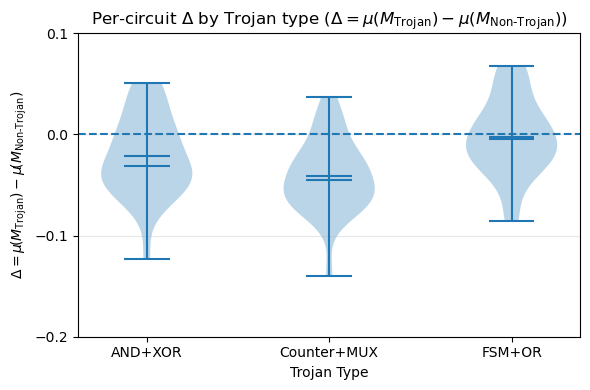

[INFO] Saved trojan_delta_distribution.pdf and .png


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

CSV_PATH = "trojan_vs_nontrojan_Mv_summary.csv"
df = pd.read_csv(CSV_PATH)

print(f"[INFO] Loaded {len(df)} rows from {CSV_PATH}")

# Ensure numeric
df["delta_mean"] = df["delta_mean"].astype(float)

print("\n================ PER-TROJAN-TYPE ? ANALYSIS ================")
print("Here $$\delta$$ = µ(M_Trojan) - µ(M_Non-Trojan)\n")

for ttype in ["andxor", "countermux", "fsmor"]:
    sub = df[df["trojan_type"] == ttype].copy()
    deltas = sub["delta_mean"].values

    mean_delta = np.mean(deltas)
    median_delta = np.median(deltas)
    frac_positive = np.mean(deltas > 0)

    print(f"--- Trojan type: {ttype} ---")
    print(f"  Files: {len(sub)}")
    print(f"  Mean ?  = µ(M_T) - µ(M_N) = {mean_delta:+.4f}")
    print(f"  Median ?= µ(M_T) - µ(M_N) = {median_delta:+.4f}")
    print(f"  Fraction with ?>0           = {frac_positive:.3f}")

    # Wilcoxon signed-rank test for ? vs 0
    try:
        stat, p = wilcoxon(deltas)
        print(f"  Wilcoxon test H0: ?=0  ? statistic={stat:.3f}, p={p:.6f}\n")
    except Exception as e:
        print(f"  Wilcoxon test failed: {e}\n")

# ------------------------------------------------
# Plot ? distribution per Trojan type
# ------------------------------------------------
plt.figure(figsize=(6,4))

data = [
    df[df["trojan_type"] == "andxor"]["delta_mean"].values,
    df[df["trojan_type"] == "countermux"]["delta_mean"].values,
    df[df["trojan_type"] == "fsmor"]["delta_mean"].values,
]
labels = ["AND+XOR", "Counter+MUX", "FSM+OR"]

# Violin plot (with means and medians)
vp = plt.violinplot(
    data,
    showmeans=True,
    showmedians=True,
)

plt.xticks([1, 2, 3], labels)
plt.yticks([-0.2,-0.1,0,0.1])

# Horizontal zero line (? = 0)
plt.axhline(0.0, linestyle="--")

# Nice LaTeX-style label
plt.ylabel(r"$\Delta = \mu\!\left(M_{\text{Trojan}}\right) - "
           r"\mu\!\left(M_{\text{Non-Trojan}}\right)$")
plt.xlabel(r'Trojan Type')

plt.title(r"Per-circuit $\Delta$ by Trojan type "
          r"($\Delta = \mu(M_{\text{Trojan}})-\mu(M_{\text{Non-Trojan}})$)")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("trojan_delta_distribution.pdf", bbox_inches="tight")
plt.savefig("trojan_delta_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("[INFO] Saved trojan_delta_distribution.pdf and .png")